# Quantitative Rotational Momentum System
## Portfolio Research & Multi-Environment Stress Testing
This notebook demonstrates the execution of the institutional momentum strategy across four distinct historical environments to quantify the exact impact of the Macro Regime Filter (SMA200).

*Note: GitHub natively renders the outputs of this notebook if it has been executed locally beforehand.*

In [31]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# Ensure the src module is accessible from the research folder
sys.path.append(os.path.abspath('..'))

from src.analysis.portfolio_backtest import PortfolioMomentumBacktester
from src.utils.static_universe import MY_HUGE_UNIVERSE

DB_FILE = os.path.join(os.path.abspath('..'), 'quant.db')
PIT_FILE = os.path.join(os.path.abspath('..'), 'sp500_historical_universe.json')

### Scenario 1: Aggressive Long-Term (NO MACRO FILTER)
We test the system from 2007 to 2026 **without** the SPY SMA200 filter. This exposes the portfolio to the full brunt of the 2008 Financial Crisis and the 2020 COVID crash, demonstrating raw momentum volatility.

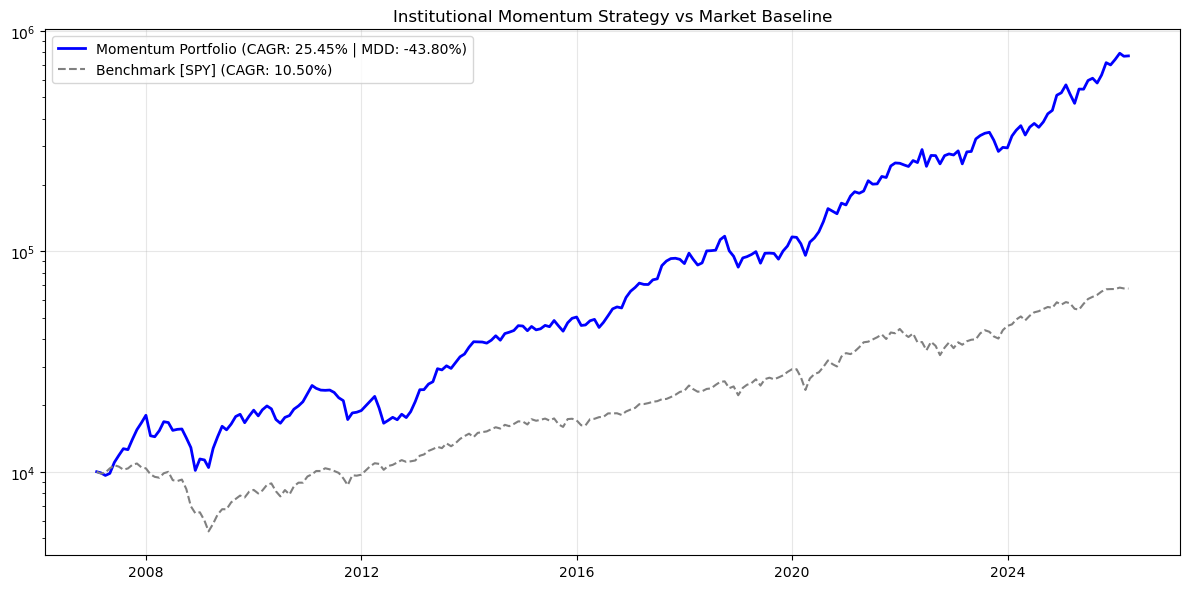

Performance Summary:
  Final Equity:    $770,466.35
  CAGR:            25.45%
  Max Drawdown:    -43.80%
  Executed Trades: 1293
  Cap. Cost:       $21,690.54


In [32]:
bt_no_filter = PortfolioMomentumBacktester(db_path=DB_FILE, universe_list=MY_HUGE_UNIVERSE, point_in_time_file=PIT_FILE)

res_no_filter = bt_no_filter.run_backtest(
    top_n=8, lookback_months=3, rebalance_freq='ME',
    crash_prob=0.0, transaction_cost=0.001, skip_recent_month=True,
    max_volatility_pct=0.15, max_per_sector=3, dividend_yield=0.015,
    market_filter_ticker=None, # FILTER DISABLED
    start_date='2007-01-01'
)

bt_no_filter.plot_results(benchmark_symbol='SPY')

### Scenario 2: Institutional Long-Term (WITH MACRO FILTER)
We test the exact same 2007-2026 period, but this time **activating the SPY SMA200 filter**. Notice the dramatic reduction in Maximum Drawdown during 2008 as the system defensively rotates to 100% Cash.

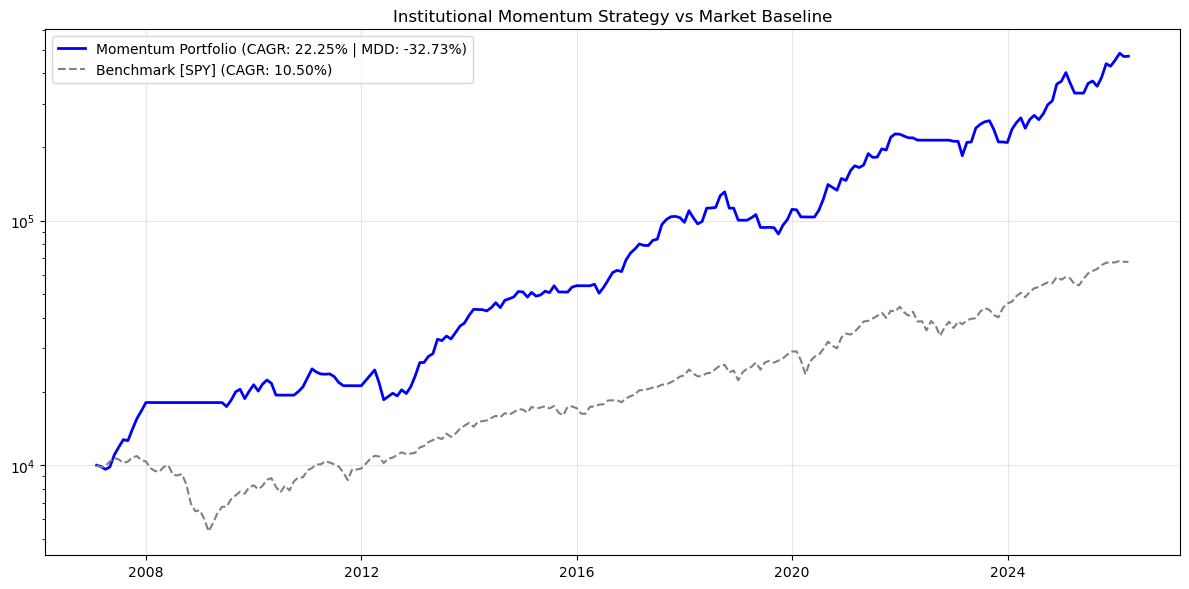

Performance Summary:
  Final Equity:    $470,004.74
  CAGR:            22.25%
  Max Drawdown:    -32.73%
  Executed Trades: 1067
  Cap. Cost:       $15,146.53


In [33]:
bt_filtered = PortfolioMomentumBacktester(db_path=DB_FILE, universe_list=MY_HUGE_UNIVERSE, point_in_time_file=PIT_FILE)

res_filtered = bt_filtered.run_backtest(
    top_n=8, lookback_months=3, rebalance_freq='ME',
    crash_prob=0.0, transaction_cost=0.001, skip_recent_month=True,
    max_volatility_pct=0.15, max_per_sector=3, dividend_yield=0.015,
    market_filter_ticker='SPY', # FILTER ENABLED
    sma_window=200,
    start_date='2007-01-01'
)

bt_filtered.plot_results(benchmark_symbol='SPY')

### Scenario 3: The 12-Year Bull Market (2014 - 2026)
A restricted test over the last decade. This environment is characterized by high liquidity and fewer systemic shocks, allowing the momentum engine to run highly efficiently.

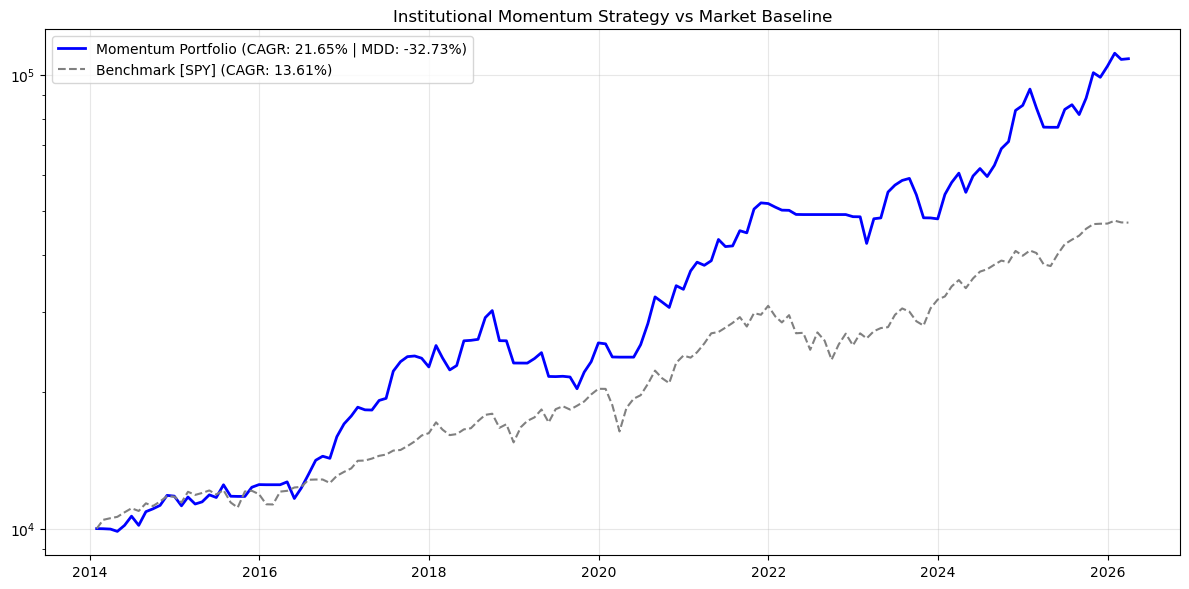

Performance Summary:
  Final Equity:    $108,431.94
  CAGR:            21.65%
  Max Drawdown:    -32.73%
  Executed Trades: 727
  Cap. Cost:       $3,276.38


In [34]:
bt_10y = PortfolioMomentumBacktester(db_path=DB_FILE, universe_list=MY_HUGE_UNIVERSE, point_in_time_file=PIT_FILE)

res_10y = bt_10y.run_backtest(
    top_n=8, lookback_months=3, rebalance_freq='ME',
    crash_prob=0.0, transaction_cost=0.001, skip_recent_month=True,
    max_volatility_pct=0.15, max_per_sector=3, dividend_yield=0.015,
    market_filter_ticker='SPY', # FILTER ENABLED
    sma_window=200,
    start_date='2014-01-01'
)

bt_10y.plot_results(benchmark_symbol='SPY')

### Scenario 4: The 7-Year Recent Window (2019 - 2026)
Testing strictly the modern era, capturing the 2020 COVID crash, the subsequent stimulus rally, and the 2022 inflationary bear market.

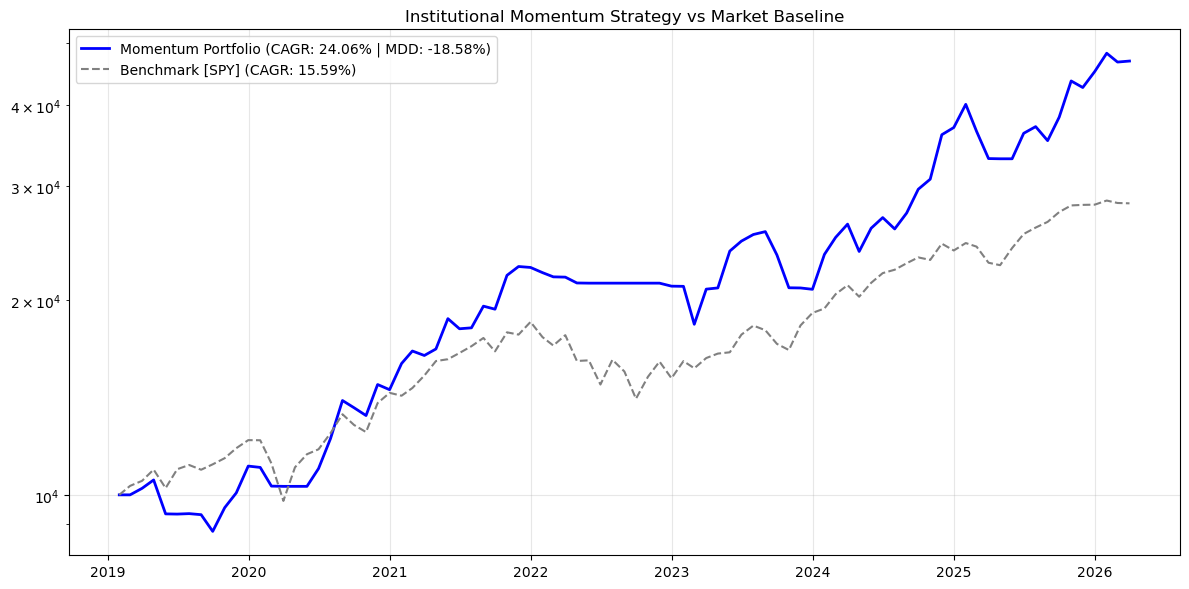

Performance Summary:
  Final Equity:    $46,832.17
  CAGR:            24.06%
  Max Drawdown:    -18.58%
  Executed Trades: 415
  Cap. Cost:       $1,133.39


In [35]:
bt_5y = PortfolioMomentumBacktester(db_path=DB_FILE, universe_list=MY_HUGE_UNIVERSE, point_in_time_file=PIT_FILE)

res_5y = bt_5y.run_backtest(
    top_n=8, lookback_months=3, rebalance_freq='ME',
    crash_prob=0.0, transaction_cost=0.001, skip_recent_month=True,
    max_volatility_pct=0.15, max_per_sector=3, dividend_yield=0.015,
    market_filter_ticker='SPY', # FILTER ENABLED
    sma_window=200,
    start_date='2019-01-01'
)

bt_5y.plot_results(benchmark_symbol='SPY')